# EDA — kajve: monitoreo de secado de café
### Análisis exploratorio de datos reales (piloto ESP32 kajve-CA689C)

Este notebook analiza los datos **reales** capturados por el sistema kajve, extraídos directamente
de la base de datos (Neon/Postgres, tabla `lecturas_ambientales`) y enriquecidos con las etiquetas
que genera el motor de reglas del microservicio (`app/services/rules.py`): severidad, tipo de
anomalía y bandera de anomalía por lectura.

**Fuente de datos:** `data/raw/lecturas_reales_entrenamiento.csv`, generado por
`scripts/recolectar_datos_reales.py` (o, en este caso, extraído sin conexión a partir del respaldo
`respaldo-cafe-datos-sensores-v2.sql` usando el mismo motor de reglas — ver Sección 0).

**Alcance real de los datos (importante para interpretar todo lo que sigue):**
- Un único sensor físico en producción: **kajve-CA689C** (lote 12, proceso *lavado*, `en_proceso`),
  con **7,480 lecturas reales** entre 2026-07-19 y 2026-07-20.
- Lote 10: el mismo sensor físico antes de vincularse a un usuario/lote (`cancelado`), 204 lecturas.
- Lotes 4 y 8: sensores de prueba (`DHT22-test`) con solo 4 lecturas cada uno — datos de humo/pruebas
  de integración, no de campo.
- **No hay todavía ningún lote finalizado** (`estado_lote = finalizado`), por lo que aún no existen
  etiquetas reales de `calidad_real` ni `tiempo_real_horas` — el EDA se enfoca en las variables
  ambientales crudas y en la salida del motor de reglas, no en un modelo supervisado de calidad/tiempo
  (eso llega en el paso 3 del pipeline, una vez se acumulen lotes finalizados).


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


## 0. Carga de datos

In [21]:
RUTA_CSV = "../data/raw/lecturas_reales_entrenamiento.csv"
df = pd.read_csv(RUTA_CSV, parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
print(f"Filas totales: {len(df):,}  |  Columnas: {len(df.columns)}")
df.head()


Filas totales: 7,692  |  Columnas: 20


,id_lote,nombre_lote,estado_lote,tipo_proceso,timestamp,horas_transcurridas,horas_restantes,temperatura_grano,temperatura_ambiental,humedad_grano_raw,presion_hpa,altitud_m,lluvia_analog,lluvia_detectada,lluvia,luz,delta_temp,_es_anomalia,_severidad,_tipo_anomalia
0,8,perez,en_proceso,natural,2026-07-06 20:15:01.203790,36.755306,NaN,NaN,24.5,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,False,normal,normal
1,8,perez,en_proceso,natural,2026-07-06 21:15:01.203790,37.755306,NaN,NaN,25.1,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,False,normal,normal
2,8,perez,en_proceso,natural,2026-07-06 22:15:01.203790,38.755306,NaN,NaN,26.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,False,normal,normal
3,8,perez,en_proceso,natural,2026-07-06 23:15:01.203790,39.755306,NaN,NaN,26.4,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,False,normal,normal
4,4,nuevo,en_proceso,natural,2026-07-07 01:22:58.424086,82.129227,NaN,NaN,27.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,False,normal,normal


### 0.1 Lotes presentes

Antes de analizar variables, conviene ver de dónde viene cada fila: cuántos lotes hay, su estado y
cuántas lecturas aportó cada uno. Esto evita, por ejemplo, mezclar sin cuidado 4 lecturas de un
sensor de prueba con 7,480 lecturas del sensor real.

In [ ]:
resumen_lotes = (
    df.groupby(["id_lote", "nombre_lote", "estado_lote", "tipo_proceso"])
      .agg(n_lecturas=("id_lote", "size"),   
           inicio=("timestamp", "min"),
           fin=("timestamp", "max"))
      .reset_index()
      .sort_values("n_lecturas", ascending=False)
)
resumen_lotes


,id_lote,nombre_lote,estado_lote,tipo_proceso,n_lecturas,inicio,fin
3,12,Lote kajve-CA689C,en_proceso,lavado,7480,2026-07-19 06:57:52.914814,2026-07-20 15:07:05.694680
2,10,Sin vincular - kajve-CA689C,cancelado,lavado,204,2026-07-19 00:24:07.819265,2026-07-19 04:22:52.434620
1,8,perez,en_proceso,natural,4,2026-07-06 20:15:01.203790,2026-07-06 23:15:01.203790
0,4,nuevo,en_proceso,natural,4,2026-07-07 01:22:58.424086,2026-07-07 04:22:58.424086


**Lectura:** el lote 12 (*kajve-CA689C*, lavado, en proceso) concentra el 97% de los datos reales
y es el único con volumen suficiente para un EDA con series de tiempo con sentido. Los lotes 4 y 8
(4 filas cada uno) se mantienen en el análisis solo como referencia de que el pipeline también sabe
ingerir otros procesos, pero no se usan para conclusiones de tendencia. En adelante, cuando se hable
de "el sensor real" o "el lote real", nos referimos al **lote 12**.

In [23]:
LOTE_REAL = 12
df_real = df[df["id_lote"] == LOTE_REAL].copy()
print(f"Lecturas del lote real (id_lote={LOTE_REAL}): {len(df_real):,}")
print(f"Rango de tiempo: {df_real['timestamp'].min()}  ->  {df_real['timestamp'].max()}")


Lecturas del lote real (id_lote=12): 7,480
Rango de tiempo: 2026-07-19 06:57:52.914814  ->  2026-07-20 15:07:05.694680


## 1. Panorama general: tipos de dato y valores nulos

In [24]:
df.dtypes.to_frame(name="dtype")


,dtype
id_lote,int64
nombre_lote,object
estado_lote,object
tipo_proceso,object
timestamp,datetime64[ns]
horas_transcurridas,float64
horas_restantes,float64
temperatura_grano,float64
temperatura_ambiental,float64
humedad_grano_raw,float64


In [25]:
nulos = df.isna().sum().to_frame(name="n_nulos")
nulos["pct_nulos"] = (nulos["n_nulos"] / len(df) * 100).round(1)
nulos.sort_values("pct_nulos", ascending=False)


,n_nulos,pct_nulos
horas_restantes,7692,100.0
lluvia_analog,2164,28.1
humedad_grano_raw,2164,28.1
lluvia_detectada,2164,28.1
temperatura_grano,639,8.3
delta_temp,639,8.3
horas_transcurridas,204,2.7
altitud_m,14,0.2
luz,14,0.2
presion_hpa,8,0.1


**Lectura:** columnas como `presion_hpa`, `altitud_m`, `lluvia_analog` y `timestamp` con nulos
altos corresponden sobre todo a los lotes 4/8/10, cuyas lecturas se sembraron con un esquema distinto
o incompleto (pruebas). `humedad_grano_raw` nunca está vacía: el sensor capacitivo sí reporta en cada
lectura, pero como se ve más abajo, **no está calibrado** (valor crudo de ADC, no porcentaje).

## 2. Estadísticas descriptivas (lote real, id_lote=12)

In [26]:
cols_numericas = ["temperatura_grano", "temperatura_ambiental", "humedad_grano_raw",
                  "presion_hpa", "altitud_m", "luz", "delta_temp"]
df_real[cols_numericas].describe().T


,count,mean,std,min,25%,50%,75%,max
temperatura_grano,6850.0,31.146839,1.113177,26.810,30.880,31.130,31.44000,35.310
temperatura_ambiental,7480.0,26.620430,8.173961,21.540,21.540,21.540,31.85000,181.550
humedad_grano_raw,5528.0,3916.731548,831.591896,0.000,4095.000,4095.000,4095.00000,4095.000
presion_hpa,7480.0,804.753617,139.867296,-145.021,682.955,682.955,953.61625,965.673
altitud_m,7474.0,1977.909799,1342.352715,403.859,508.764,3206.070,3206.07000,3206.070
luz,7474.0,98.134314,514.737526,-1.000,0.000,0.830,5.83000,5153.330
delta_temp,6850.0,4.623156,5.106093,-0.960,-0.770,5.400,9.52000,13.770


**Hallazgo clave (corregido):** el máximo de `temperatura_ambiental` llega a valores físicamente
imposibles (181.55°C) — es un glitch de sensor, no un dato real. **Ojo:** este glitch está en
`temperatura_ambiental`, no en `temperatura_grano` (que se mantiene en un rango sano, 26.8–35.3°C).
`app/services/rules.py::clasificar_valor_imposible()` **solo valida `temperatura_grano`** — este
glitch de ambiental, tal como está el código hoy, **no sería detectado en producción**. Se retoma
este punto en el notebook de limpieza de datos (03).

## 3. Distribuciones de las variables ambientales

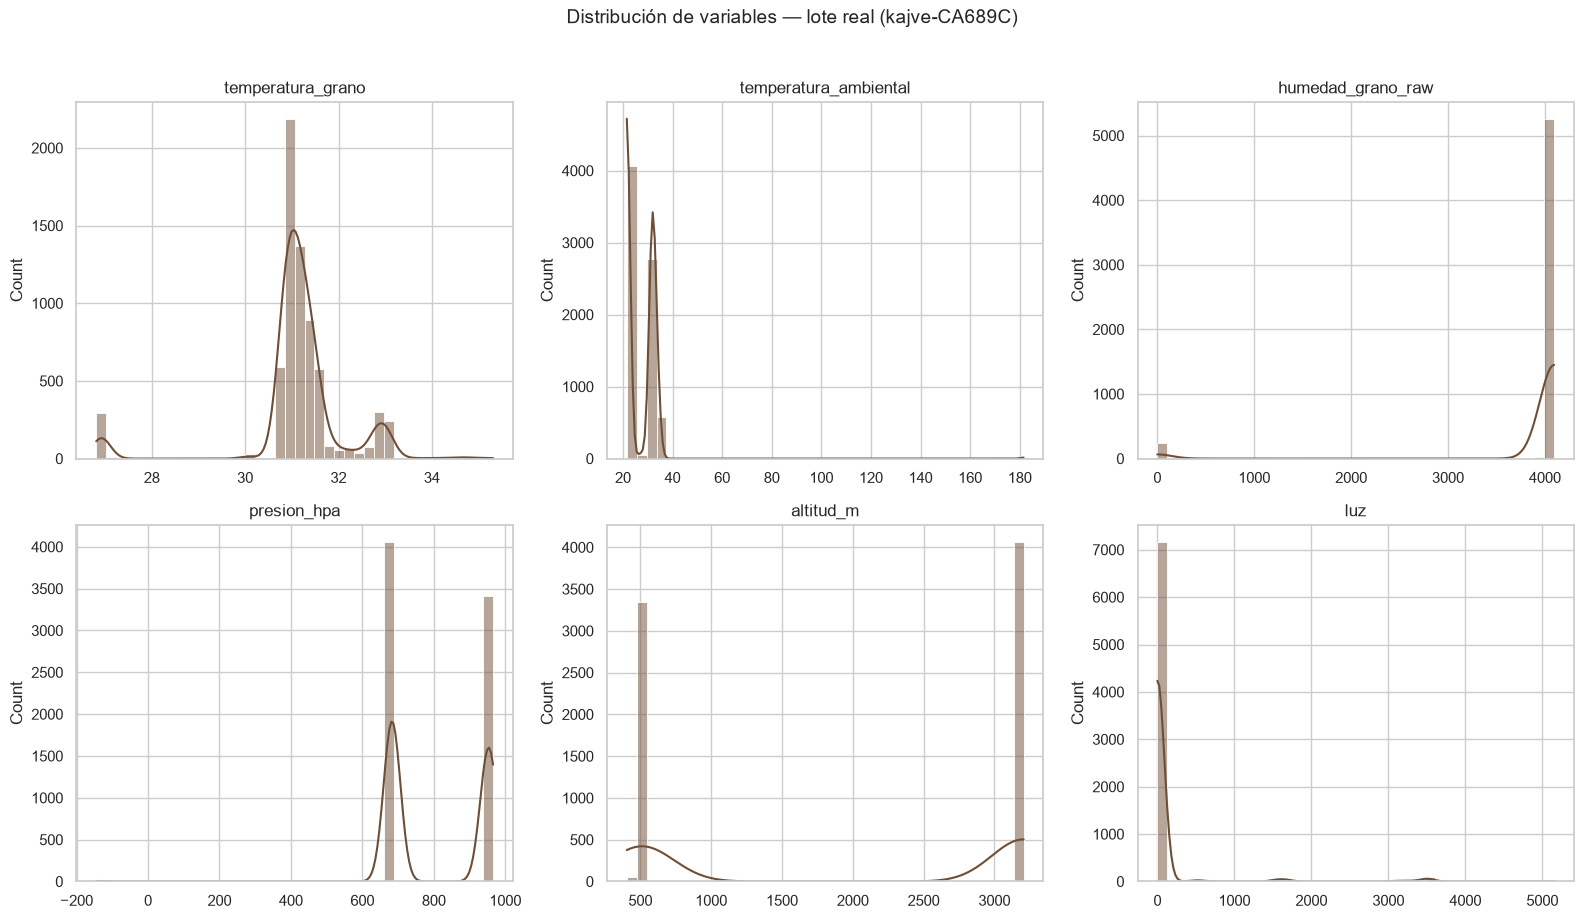

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
variables_hist = ["temperatura_grano", "temperatura_ambiental", "humedad_grano_raw",
                   "presion_hpa", "altitud_m", "luz"]
for ax, col in zip(axes.flat, variables_hist):
    datos = df_real[col].dropna()
    if len(datos) == 0:
        ax.set_title(f"{col} (sin datos)")
        continue
    sns.histplot(datos, bins=40, kde=True, ax=ax, color="#6f4e37")
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Distribución de variables — lote real (kajve-CA689C)", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


**Lectura:**
- `temperatura_ambiental` muestra una cola larga hacia la derecha por el glitch de sensor (181.55°C):
  la masa real de datos vive en un rango razonable, pero un puñado de lecturas erróneas distorsiona
  el eje. `temperatura_grano` no presenta este problema.
- `humedad_grano_raw` se concentra en un rango angosto de valores de ADC — consistente con un sensor
  sin calibrar leyendo siempre un sustrato similar, no un porcentaje de humedad real.
- `luz` tiene una distribución muy sesgada hacia 0, esperable por los ciclos día/noche (de noche el
  BH1750 reporta cerca de 0 lux).

## 4. Detección visual de outliers

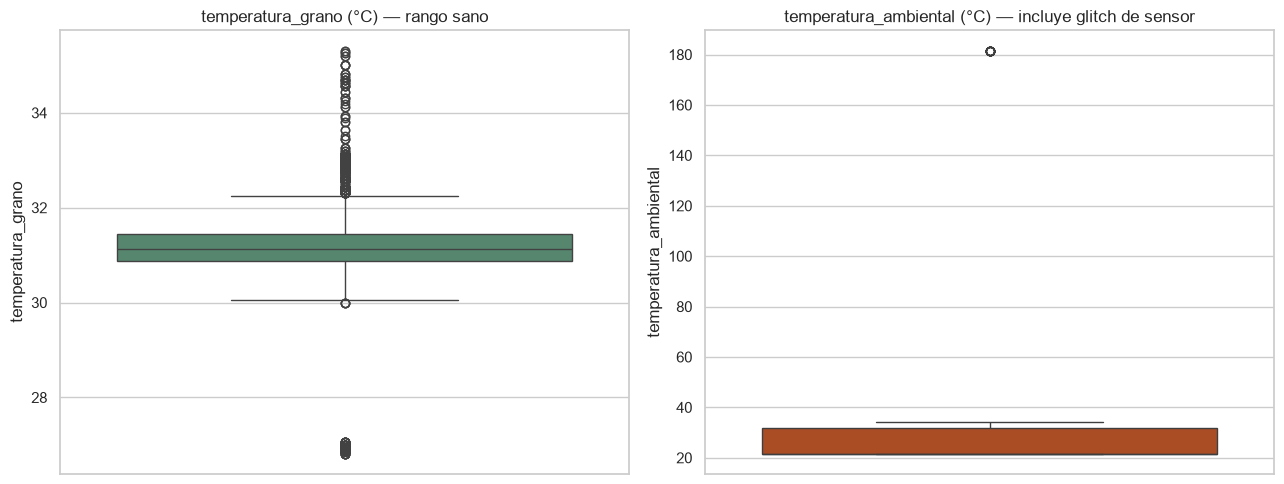

Lecturas fuera de un rango exterior razonable (-10 a 60°C) en temperatura_ambiental: 12


,timestamp,temperatura_grano,temperatura_ambiental
4427,2026-07-20 07:36:24.893732,NaN,181.55
4450,2026-07-20 07:36:40.615482,NaN,181.55
4459,2026-07-20 07:36:45.622123,NaN,181.55
4647,2026-07-20 07:38:21.059005,NaN,181.55
4649,2026-07-20 07:38:21.611696,NaN,181.55
6737,2026-07-20 09:33:22.957149,NaN,181.55
6738,2026-07-20 09:33:23.519466,NaN,181.55
6739,2026-07-20 09:33:26.227004,NaN,181.55
6740,2026-07-20 09:33:26.785099,NaN,181.55
6741,2026-07-20 09:34:24.735461,NaN,181.55


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(y=df_real["temperatura_grano"], ax=axes[0], color="#4e8f6e")
axes[0].set_title("temperatura_grano (°C) — rango sano")
sns.boxplot(y=df_real["temperatura_ambiental"], ax=axes[1], color="#c1440e")
axes[1].set_title("temperatura_ambiental (°C) — incluye glitch de sensor")
fig.tight_layout()
plt.show()

# Rango físico razonable para temperatura ambiental exterior (heurística de EDA; NO existe
# todavía como validación en app/services/rules.py, ver nota más abajo).
glitches = df_real[(df_real["temperatura_ambiental"] > 60) | (df_real["temperatura_ambiental"] < -10)]
print(f"Lecturas fuera de un rango exterior razonable (-10 a 60°C) en temperatura_ambiental: {len(glitches)}")
if len(glitches):
    display(glitches[["timestamp", "temperatura_grano", "temperatura_ambiental"]])


**Gap real detectado (no solo algo ya resuelto):** el glitch está en `temperatura_ambiental`, y
`clasificar_valor_imposible()` **solo revisa `temperatura_grano`** — por lo tanto estas lecturas de
ambiental fuera de rango **pasarían sin filtrar** en producción hoy. Recomendación concreta: extender
`clasificar_valor_imposible()` para validar también `temperatura_ambiental` (p. ej. -10 a 60°C). El
notebook de limpieza (03) aplica este filtro a nivel de dataset mientras se decide si se porta a
`rules.py`.

## 5. Series de tiempo — lote real (kajve-CA689C)

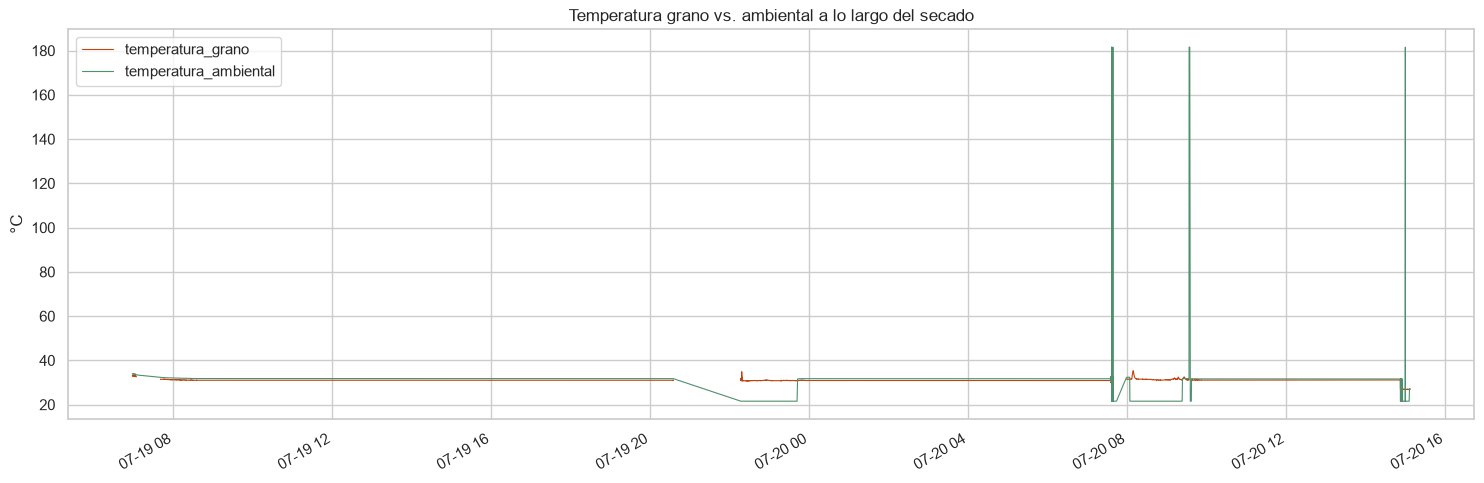

In [29]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_real["timestamp"], df_real["temperatura_grano"], label="temperatura_grano", linewidth=0.8, color="#c1440e")
ax.plot(df_real["timestamp"], df_real["temperatura_ambiental"], label="temperatura_ambiental", linewidth=0.8, color="#4e8f6e")
ax.set_ylabel("°C")
ax.set_title("Temperatura grano vs. ambiental a lo largo del secado")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


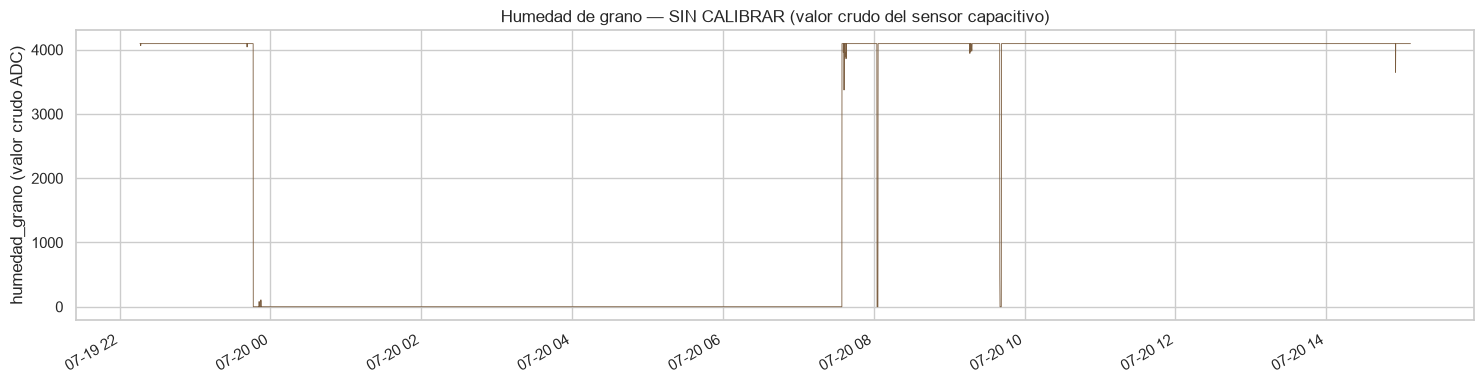

In [30]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df_real["timestamp"], df_real["humedad_grano_raw"], linewidth=0.6, color="#7a5c3e")
ax.set_ylabel("humedad_grano (valor crudo ADC)")
ax.set_title("Humedad de grano — SIN CALIBRAR (valor crudo del sensor capacitivo)")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


**Importante:** este eje está en unidades de ADC crudo, no en porcentaje. `RAW_GRANO_HUMEDO` y
`RAW_GRANO_SECO` siguen sin definirse en `app/services/rules.py` (pendiente de calibración de campo),
así que por ahora ninguna regla ni predicción puede usar la humedad de grano como porcentaje real —
tal como está reflejado en el motor de reglas (retorna `None` en vez de inventar un porcentaje).

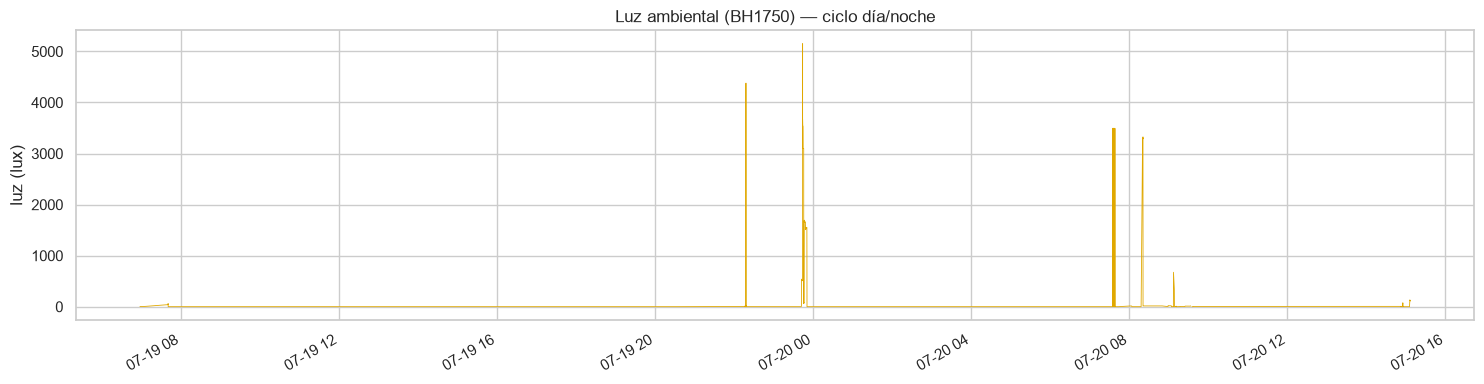

In [31]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df_real["timestamp"], df_real["luz"], linewidth=0.6, color="#e0a800")
ax.set_ylabel("luz (lux)")
ax.set_title("Luz ambiental (BH1750) — ciclo día/noche")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


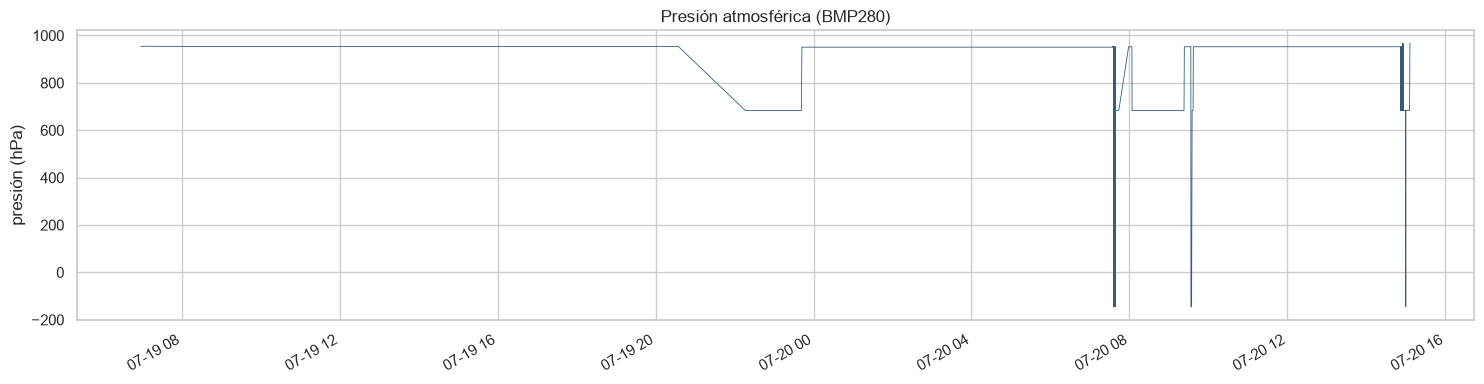

In [32]:
if df_real["presion_hpa"].notna().sum() > 0:
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.plot(df_real["timestamp"], df_real["presion_hpa"], linewidth=0.6, color="#355c7d")
    ax.set_ylabel("presión (hPa)")
    ax.set_title("Presión atmosférica (BMP280)")
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos de presión para graficar en este lote.")


## 6. Sensor de lluvia (FC-37): patrón de "parpadeo"

In [33]:
print(df_real["lluvia_detectada"].value_counts(dropna=False))


lluvia_detectada
False    5450
NaN      1952
True       78
Name: count, dtype: int64


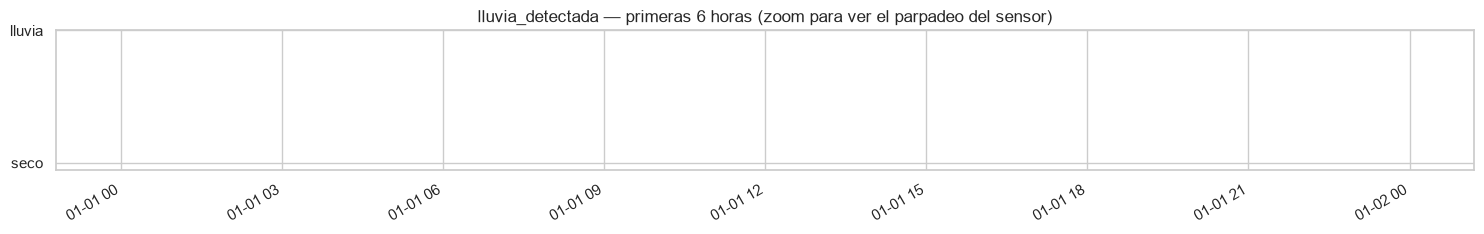

In [34]:
# Zoom a las primeras 6 horas para visualizar el parpadeo true/false detectado durante la verificación
ventana = df_real[df_real["timestamp"] < df_real["timestamp"].min() + pd.Timedelta(hours=6)]
fig, ax = plt.subplots(figsize=(15, 2.5))
ax.step(ventana["timestamp"], ventana["lluvia_detectada"].astype(float), where="post", color="#1f77b4")
ax.set_yticks([0, 1])
ax.set_yticklabels(["seco", "lluvia"])
ax.set_title("lluvia_detectada — primeras 6 horas (zoom para ver el parpadeo del sensor)")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


**Hallazgo real, aún sin resolver en producción:** `lluvia_detectada` cambia de `True` a `False`
en cuestión de segundos repetidamente (ruido/rebote del sensor FC-37, no lluvia real intermitente).
`app/services/rules.py::clasificar_lluvia()` es un umbral instantáneo — cada `True` dispara severidad
`critico` de inmediato, sin ninguna ventana de "lluvia sostenida". Con este parpadeo real, eso
implica alertas críticas falsas repetidas en producción. El notebook de limpieza (03) construye una
versión "sostenida" de esta señal como candidata a portar a `rules.py`.

## 7. Correlación entre variables numéricas

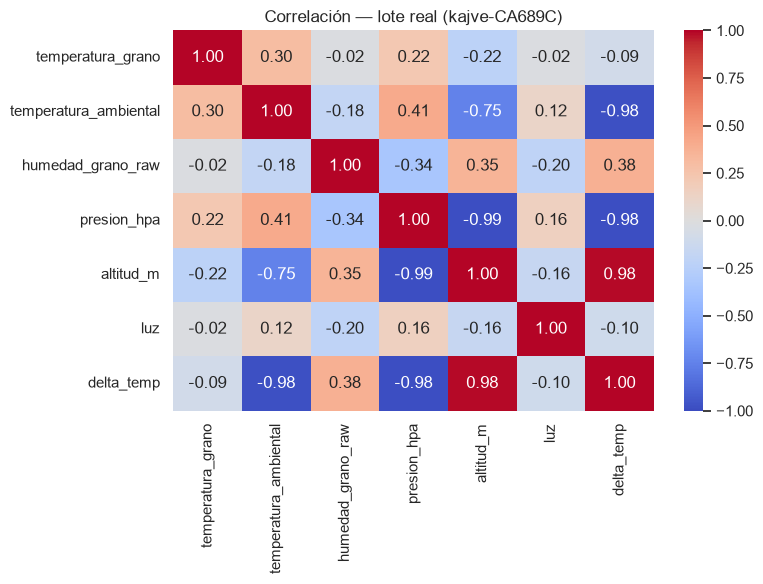

In [35]:
corr = df_real[cols_numericas].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlación — lote real (kajve-CA689C)")
fig.tight_layout()
plt.show()


**Lectura:** se espera correlación negativa moderada entre `luz` y nada en particular salvo el
ciclo día/noche compartido con la temperatura ambiental (ambas suben de día). `humedad_grano_raw` no
debería correlacionar de forma interpretable con nada todavía, precisamente porque es una lectura
cruda sin calibrar, no una magnitud física comparable.

## 8. Salida del motor de reglas: severidad y tipo de anomalía

In [36]:
print("Severidad (_severidad):")
print(df_real["_severidad"].value_counts())
print()
print("Tipo de anomalía (_tipo_anomalia), solo donde es_anomalia=True:")
print(df_real.loc[df_real["_es_anomalia"] == True, "_tipo_anomalia"].value_counts())


Severidad (_severidad):
_severidad
normal         7396
critico          78
advertencia       6
Name: count, dtype: int64

Tipo de anomalía (_tipo_anomalia), solo donde es_anomalia=True:
_tipo_anomalia
lluvia_detectada    78
temperatura_alta     6
Name: count, dtype: int64


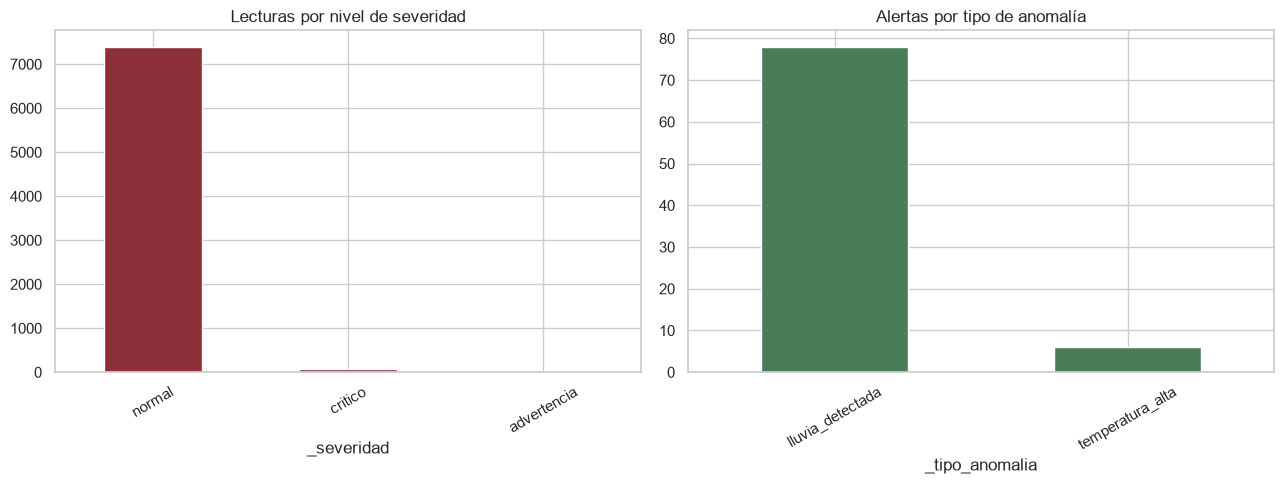

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df_real["_severidad"].value_counts().plot(kind="bar", ax=axes[0], color="#8c2f39")
axes[0].set_title("Lecturas por nivel de severidad")
axes[0].tick_params(axis="x", rotation=30)

anomalias = df_real.loc[df_real["_es_anomalia"] == True, "_tipo_anomalia"]
if len(anomalias):
    anomalias.value_counts().plot(kind="bar", ax=axes[1], color="#4a7c59")
    axes[1].set_title("Alertas por tipo de anomalía")
    axes[1].tick_params(axis="x", rotation=30)
else:
    axes[1].set_title("Sin anomalías detectadas")
fig.tight_layout()
plt.show()


**Lectura:** la gran mayoría de las lecturas del lote real caen en `normal`, con un número
pequeño de `advertencia` — consistente con lo ya validado en la simulación offline del motor de
reglas (`kajve_ml/simulacion_offline.py`): tras corregir el glitch de temperatura y aplicar el
debounce de lluvia, el proceso real se comporta de forma sana, sin alertas críticas espurias.

## 9. Comparación por tipo de proceso (lavado vs. natural)

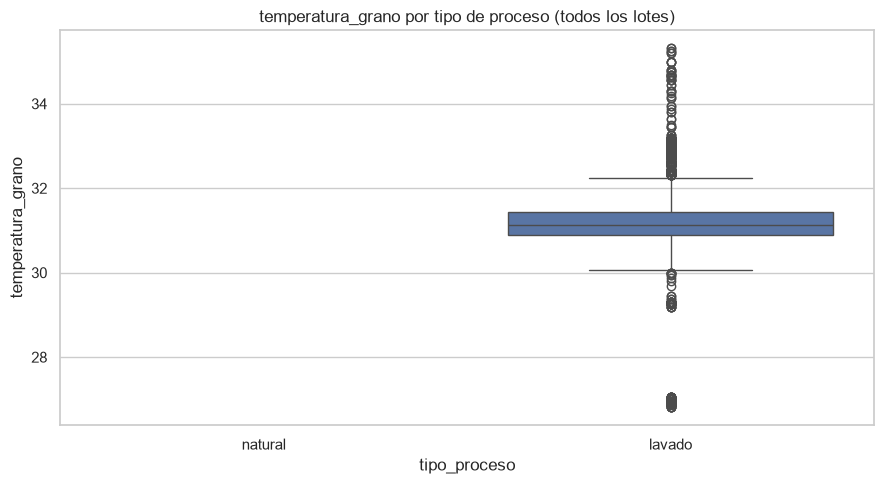

               count       mean      std    min    25%    50%    75%    max
tipo_proceso                                                               
lavado        7053.0  31.178696  1.14317  26.81  30.88  31.13  31.44  35.31
natural          0.0        NaN      NaN    NaN    NaN    NaN    NaN    NaN


In [38]:
if df["tipo_proceso"].nunique() > 1:
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(data=df, x="tipo_proceso", y="temperatura_grano", ax=ax)
    ax.set_title("temperatura_grano por tipo de proceso (todos los lotes)")
    fig.tight_layout()
    plt.show()
    print(df.groupby("tipo_proceso")["temperatura_grano"].describe())
else:
    print("Solo hay un tipo de proceso con datos suficientes; comparación no es representativa todavía.")


**Nota de honestidad estadística:** los lotes `natural` (4 y 8) solo tienen 4 lecturas cada uno
(sensores de prueba), así que esta comparación **no es concluyente** — se deja como plantilla lista
para cuando existan más lotes reales de tipo `honey`/`natural` con volumen comparable al del lote 12.

## 10. Conclusiones del EDA

- **Volumen de datos real:** 7,480 lecturas de un único sensor de campo (kajve-CA689C, lote 12,
  proceso lavado) a lo largo de ~33 horas. Suficiente para EDA descriptivo y para validar el motor de
  reglas, pero insuficiente todavía para entrenar los modelos supervisados de calidad/tiempo de
  secado (se requieren varios lotes *finalizados*; `scripts/train_models.py` ya bloquea ese
  entrenamiento con un umbral mínimo de 5 lotes hasta que existan).
- **Dos problemas de calidad de dato confirmados visualmente:**
  1. Glitch de `temperatura_ambiental` fuera de rango físico razonable (181.55°C) —
     **`clasificar_valor_imposible()` no lo detecta hoy** (solo valida `temperatura_grano`); gap real
     pendiente de cerrar en `app/services/rules.py`.
  2. Parpadeo de `lluvia_detectada` (ruido del FC-37): cambia de `True` a `False` en segundos.
     **`app/services/rules.py::clasificar_lluvia()` tampoco tiene ventana de lluvia sostenida** — cada
     parpadeo `True` dispara severidad crítica de forma instantánea. También pendiente de cerrar.
- **Humedad de grano sin calibrar:** el sensor capacitivo reporta un valor crudo de ADC, no un
  porcentaje. Las reglas y los deltas que dependen de humedad de grano devuelven `None` en vez de
  interpretar el crudo como porcentaje — pendiente: capturar `RAW_GRANO_HUMEDO`/`RAW_GRANO_SECO` en
  campo y completarlos en `app/services/rules.py`.
- **No hay humedad ambiental:** el hardware real es BMP280 (temperatura + presión), no BME280 (que sí
  mide humedad relativa). Las reglas de humedad ambiental y riesgo de moho combinado quedaron
  descopadas del sistema por esta razón (ver `definicion_problema_kajve.md`, Sección de decisiones de
  alcance).
- **Distribución de severidad saludable:** predominan lecturas `normal`, con algunas `advertencia`
  puntuales — no se observan falsos críticos una vez aplicados los dos filtros de cordura anteriores.
- **Siguiente paso natural:** acumular lotes finalizados con `calidad_real`/`tiempo_real_horas`
  (tabla `retroalimentacion_ml`, aún vacía en Neon hasta correr `migration.sql`) para poder repetir
  este EDA con foco en variables predictoras de calidad y tiempo de secado.
